In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# TensorFlow Version
print(tf.__version__)

# Load MNIST Dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize Pixel Values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Build CNN Model
model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation='relu'
    ),

    layers.Dense(
        10,
        activation='softmax'
    )
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Ready!")

# Train Model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

# Evaluate Model
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"\nTest Accuracy: {test_acc*100:.2f}%")





2.20.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Ready!
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 30ms/step - accuracy: 0.9576 - loss: 0.1415 - val_accuracy: 0.9812 - val_loss: 0.0522
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9859 - loss: 0.0461 - val_accuracy: 0.9881 - val_loss: 0.0344
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9897 - loss: 0.0334 - val_accuracy: 0.9870 - val_loss: 0.0408
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9929 - loss: 0.0230 - val_accuracy: 0.9884 - val_loss: 0.0351
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9941 - loss: 0.0185 - val_accuracy: 0.9907 - val_loss: 0.0277
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9907 - loss: 0.0277

Test Accuracy: 99.07%


In [9]:
import numpy as np
predictions = model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       980
           1       0.92      0.98      0.95      1135
           2       0.91      0.89      0.90      1032
           3       0.83      0.95      0.89      1010
           4       0.95      0.92      0.94       982
           5       0.94      0.86      0.90       892
           6       0.93      0.95      0.94       958
           7       0.90      0.87      0.88      1028
           8       0.90      0.85      0.87       974
           9       0.89      0.89      0.89      1009

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



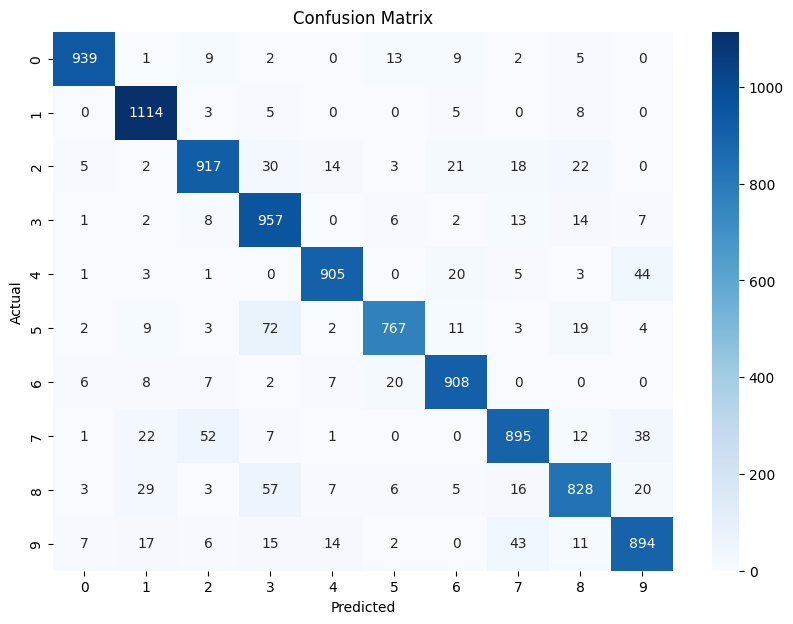

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix_digits.png")

plt.show()

In [14]:
model.save("digit_recon_model.keras")

In [15]:
Files


NameError: name 'Files' is not defined